# Chapter 166 — Rotations via Matrices

> **Prerequisites:** Trigonometry *(ch102–103)*, matrix visualization *(ch165)*
> **You will learn:**
> - 2D rotation matrix derivation from first principles
> - 3D rotation matrices (Rx, Ry, Rz) and their composition
> - Gimbal lock: why Euler angles are problematic
> - Orthogonal matrices and why rotation matrices satisfy RᵀR = I
>
> **Environment:** Python 3.x, numpy, matplotlib

2D rotation (60°):
  R =
[[ 0.5   -0.866]
 [ 0.866  0.5  ]]
  det(R) = 1.0000  (should be 1)
  RᵀR = I: True
  Rᵀ = R⁻¹: True

3D composed rotation: det=1.0000, RᵀR=I: True


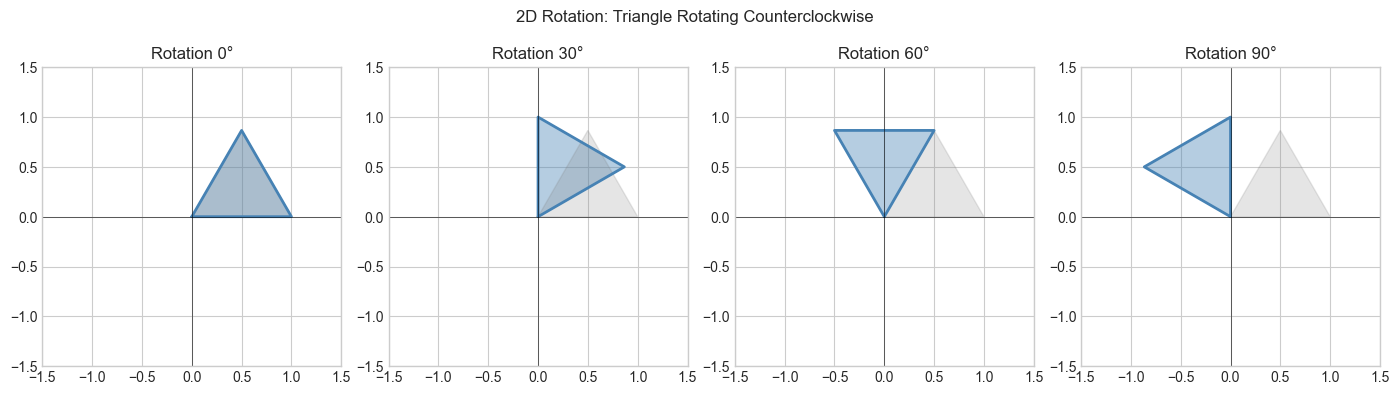

In [1]:
# --- 2D and 3D Rotation Matrices ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def rot2d(theta):
    """2D rotation matrix: rotates counterclockwise by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def rotx(theta):
    """3D rotation about x-axis by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]])

def roty(theta):
    """3D rotation about y-axis by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]])

def rotz(theta):
    """3D rotation about z-axis by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

# Verify properties of rotation matrices
R = rot2d(np.pi/3)
print("2D rotation (60°):")
print(f"  R =\n{np.round(R,4)}")
print(f"  det(R) = {np.linalg.det(R):.4f}  (should be 1)")
print(f"  RᵀR = I: {np.allclose(R.T @ R, np.eye(2))}")
print(f"  Rᵀ = R⁻¹: {np.allclose(R.T, np.linalg.inv(R))}\n")

# 3D rotation composition
Rx = rotx(np.pi/6); Ry = roty(np.pi/4); Rz = rotz(np.pi/3)
R3 = Rz @ Ry @ Rx
print(f"3D composed rotation: det={np.linalg.det(R3):.4f}, RᵀR=I: {np.allclose(R3.T@R3, np.eye(3))}")

# Visualization: rotate a triangle
triangle = np.array([[0,1,0.5,0],[0,0,0.866,0]], dtype=float)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
angles = [0, np.pi/6, np.pi/3, np.pi/2]
labels = ['0°','30°','60°','90°']
for ax, theta, label in zip(axes, angles, labels):
    R = rot2d(theta)
    rotated = R @ triangle
    ax.fill(rotated[0], rotated[1], alpha=0.4, color='steelblue')
    ax.plot(rotated[0], rotated[1], 'steelblue', lw=2)
    ax.fill(triangle[0], triangle[1], alpha=0.2, color='gray')
    ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.set_aspect('equal')
    ax.axhline(0,color='k',lw=0.4); ax.axvline(0,color='k',lw=0.4)
    ax.set_title(f'Rotation {label}')
plt.suptitle('2D Rotation: Triangle Rotating Counterclockwise', fontsize=12)
plt.tight_layout(); plt.show()

---

## 4. Mathematical Formulation

```
2D rotation by θ (counterclockwise):
  R(θ) = [[cos θ, -sin θ],
           [sin θ,  cos θ]]

Derivation: e₁=[1,0] maps to [cos θ, sin θ]; e₂=[0,1] maps to [-sin θ, cos θ]

3D rotations about coordinate axes:
  Rx(θ): [[1,0,0],[0,c,-s],[0,s,c]]     c=cos θ, s=sin θ
  Ry(θ): [[c,0,s],[0,1,0],[-s,0,c]]
  Rz(θ): [[c,-s,0],[s,c,0],[0,0,1]]

Key properties of rotation matrices (orthogonal matrices):
  RᵀR = I      (columns/rows are orthonormal)
  det(R) = 1   (preserves orientation AND volume)
  R⁻¹ = Rᵀ    (inverse is free — just transpose)
  R(θ₁) @ R(θ₂) = R(θ₁+θ₂)  (compose = add angles, for 2D)
```

---

## 7. Exercises

**Easy 1.** What is `rot2d(π/2) @ rot2d(π/2)`? Compute and interpret.

**Easy 2.** Verify that `rotx(θ)` has det=1 and satisfies RᵀR=I for θ=π/7.

**Medium 1.** Implement `rot_axis_angle(axis, theta)` that rotates about an arbitrary unit vector axis using Rodrigues' rotation formula.

**Medium 2.** Show that 3D rotations about different axes don't commute: `Rx @ Ry ≠ Ry @ Rx`. Visualize the difference by rotating a cube.

**Hard.** Demonstrate gimbal lock: find a sequence of Euler angles where two rotation axes align (one degree of freedom is lost). Show that rotating Rz @ Ry(π/2) @ Rx achieves the same rotation as Rz @ Rx (the y rotation fused x and z).

---

## 9. Chapter Summary & Connections

- 2D rotation: `R(θ) = [[cos θ, -sin θ],[sin θ, cos θ]]`. Derived from where basis vectors land.
- Rotation matrices are orthogonal: `RᵀR = I`, `det(R) = 1`, `R⁻¹ = Rᵀ`.
- 3D rotations don't commute; Euler angle order matters *(connects to ch114 — Affine Transformations)*.

**Forward connections:**
- In ch172 (Diagonalization), rotation matrices appear as the Q in eigendecomposition.
- In ch177 (Linear Algebra for Neural Networks), orthogonal weight matrices preserve gradient norms during backpropagation.